In [ ]:
Classification-->Churn_Modelling

Shape: (10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
RowNumber          0
CustomerId         0
Surname            0
CreditS

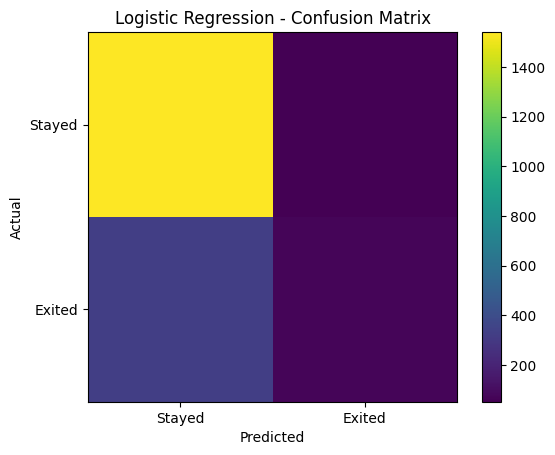

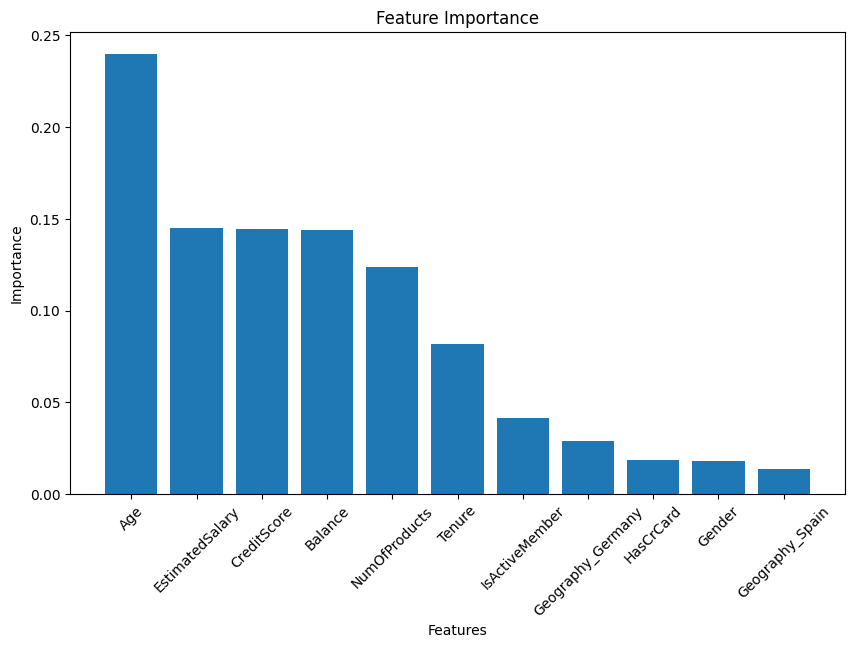

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# 1. Load Dataset
df = pd.read_csv("/content/Churn_Modelling.csv")

# 2. Explore Dataset
print("Shape:", df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe())

# 3. Handle Categorical Data

# Drop unnecessary columns
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)

# Encode Gender column
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

# Convert Geography into dummy variables
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

# 4. Define X and Target
X = df.drop("Exited", axis=1)
y = df["Exited"]

# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 6. Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 7. Create Model
model = LogisticRegression(random_state=42)

# 8. Train Model
model.fit(X_train, y_train)

# 9. Prediction
y_pred = model.predict(X_test)

# 10. Model Parameters
print("\nCoefficients:", model.coef_[0])
print("Intercept:", model.intercept_[0])

# 11. Evaluation

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# 12. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# 13. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 14. Plot Confusion Matrix

plt.imshow(cm)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.colorbar()

plt.xticks([0, 1], ["Stayed", "Exited"])
plt.yticks([0, 1], ["Stayed", "Exited"])

# 15. Feature Importance

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

feature_importance = rf_model.feature_importances_

# Get feature names from the original DataFrame X
feature_names = X.columns.tolist()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(importance_df)

# 16. Plot Feature Importance

plt.figure(figsize=(10, 6))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.xticks(rotation=45)

plt.show()